# P3_608995
## Proyecto Final – Unidad 3
**José Ricardo Jáuregui Guevara – 608995**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.stats import kruskal, chi2_contingency
from statsmodels.stats.multitest import multipletests

import warnings
warnings.filterwarnings('ignore')

## Planteamiento del problema y contexto de los datos

### Tipo de cáncer: Carcinoma de Células Renales Claras (KIRC)

El carcinoma de células renales claras (Kidney Renal Clear Cell Carcinoma, KIRC) es la forma más frecuente de cáncer renal en adultos, representando aproximadamente el 75 % de todos los tumores renales malignos. A nivel molecular se caracteriza por la pérdida del gen supresor de tumores VHL (von Hippel-Lindau) en el cromosoma 3p, lo que activa la vía HIF y promueve la angiogénesis aberrante.

A pesar de los avances en inmunoterapia y terapias dirigidas, el KIRC metastásico sigue siendo en gran medida incurable, con tasas de supervivencia a 5 años menores al 13 % en estadios avanzados. La heterogeneidad molecular del tumor dificulta la selección de tratamientos óptimos, motivando la búsqueda de subtipos moleculares con comportamiento clínico distinto.

### Objetivo del análisis

El proyecto busca identificar subgrupos moleculares en los tumores de KIRC a partir de su perfil de expresión génica global, aplicando técnicas de aprendizaje no supervisado. La hipótesis de trabajo es que existen agrupaciones de pacientes con patrones de expresión génica similares que se corresponden con diferencias clínicas relevantes como estadio, grado tumoral o supervivencia y que no pueden identificarse fácilmente con variables clínicas convencionales.

### Origen y descripción de los datos

Los datos provienen de The Cancer Genome Atlas (TCGA) y fueron accedidos a través de UCSC Xena, seleccionando la cohorte GDC TCGA Kidney Clear Cell Carcinoma (KIRC). Se trabajó con tres archivos:

| Archivo | Contenido |
|---|---|
| `TCGA-KIRC.star_tpm.tsv.gz` | Expresión génica (STAR–TPM), n = 610 muestras |
| `TCGA-KIRC.clinical.tsv.gz` | Variables clínicas (fenotipo) |
| `TCGA-KIRC.survival.tsv.gz` | Datos de supervivencia |

La expresión génica se midió mediante RNA-seq con cuantificación en TPM. Los IDs de genes son identificadores Ensembl (ENSG…); se mapearán a símbolos génicos con MyGene.info tras el filtrado por varianza.

Conforme a las instrucciones del proyecto, el clustering se realizará exclusivamente con los datos de expresión génica. Los datos clínicos se incorporan únicamente en la etapa de interpretación posterior.

## Exploración y comprensión del conjunto de datos

### Carga de datos de expresión génica

In [2]:
# Carga del archivo de expresión génica
# Formato GDC / UCSC Xena STAR-TPM:
#   Filas - genes (Ensembl ID con versión, e.g. ENSG00000000003.15)
#   Columnas - barcodes de muestras TCGA
#   Valores - TPM sin transformar

expr_raw = pd.read_csv('TCGA-KIRC.star_tpm.tsv.gz', sep='\t', index_col=0)

print(f'Dimensiones (genes × muestras): {expr_raw.shape}')
expr_raw.iloc[:5, :4]

Dimensiones (genes × muestras): (60660, 610)


,TCGA-CW-5584-01A,TCGA-CZ-5984-01A,TCGA-B0-4841-01A,TCGA-B0-4700-01A
Ensembl_ID,,,,
ENSG00000000003.15,5.411094,6.204196,3.223361,4.817342
ENSG00000000005.6,1.332679,0.678883,1.334854,0.553164
ENSG00000000419.13,5.803106,6.358955,3.857812,5.969728
ENSG00000000457.14,2.378373,2.489980,1.148934,2.203953
ENSG00000000460.17,1.578262,1.780268,0.376290,1.368433


Se lee el archivo comprimido TCGA-KIRC.star_tpm.tsv.gz que contiene los valores TPM de expresión. Cada fila corresponde a un gen (identificado por su Ensembl ID con versión) y cada columna a una muestra TCGA. Después de cargarlo, imprimimos las dimensiones (genes × muestras) y mostramos las primeras 5 filas y 4 columnas para confirmar que los datos se importaron correctamente.

TPM significa Transcripts Per Million (transcritos por millón). Es una unidad que se usa para medir la expresión de un gen en experimentos de RNA-seq. Básicamente, indica cuántas copias de ARN mensajero de ese gen hay por cada millón de moléculas de ARN totales en la muestra, después de corregir por la longitud del gen y la profundidad total de la secuenciación. Así, los valores TPM permiten comparar genes entre distintas muestras de forma más justa, porque eliminan sesgos técnicos.

In [3]:
# Limpieza del índice: eliminamos el número de versión del Ensembl ID
# ENSG00000000003.15 → ENSG00000000003

expr_raw.index = expr_raw.index.str.split('.').str[0]
expr_raw = expr_raw[~expr_raw.index.duplicated(keep='first')]

print(f'Dimensiones tras limpiar versiones: {expr_raw.shape}')
print('Muestra de IDs en el índice:')
print(expr_raw.index[:5].tolist())

Dimensiones tras limpiar versiones: (60616, 610)
Muestra de IDs en el índice:
['ENSG00000000003', 'ENSG00000000005', 'ENSG00000000419', 'ENSG00000000457', 'ENSG00000000460']


Eliminamos la versión de cada Ensembl ID (p. ej. `.15`) para evitar duplicados y facilitar el mapeo a símbolos génicos. Después conservamos solo la primera aparición de cada gen y revisamos el resultado.

### Carga de datos clínicos

In [4]:
# Archivo de fenotipo clínico
pheno = pd.read_csv('TCGA-KIRC.clinical.tsv.gz', sep='\t', index_col=0)
print(f'Dimensiones fenotipo: {pheno.shape}')
pheno.head(3)

Dimensiones fenotipo: (950, 89)


,id,disease_type,case_id,submitter_id,primary_site,cigarettes_per_day.exposures,alcohol_history.exposures,years_smoked.exposures,race.demographic,gender.demographic,...,initial_weight.samples,preservation_method.samples,intermediate_dimension.samples,pathology_report_uuid.samples,shortest_dimension.samples,oct_embedded.samples,specimen_type.samples,longest_dimension.samples,is_ffpe.samples,tissue_type.samples
sample,,,,,,,,,,,,,,,,,,,,,
TCGA-B0-5695-01A,fb9bafa5-7133-4955-8156-4eb6763dc8e1,Adenomas and Adenocarcinomas,fb9bafa5-7133-4955-8156-4eb6763dc8e1,TCGA-B0-5695,Kidney,NaN,Not Reported,NaN,white,female,...,NaN,Unknown,2.0,0c40b9ba-a1e4-4e11-904d-4fd2a1564f76,0.4,NaN,Unknown,2.5,False,Tumor
TCGA-BP-4807-01A,33cf0893-0411-4758-aa90-602bfedf0850,Adenomas and Adenocarcinomas,33cf0893-0411-4758-aa90-602bfedf0850,TCGA-BP-4807,Kidney,NaN,Not Reported,NaN,white,male,...,NaN,Unknown,0.7,e90ebecf-b60a-42a1-9399-1a429093bd29,0.2,NaN,Unknown,1.3,False,Tumor
TCGA-BP-4807-11A,33cf0893-0411-4758-aa90-602bfedf0850,Adenomas and Adenocarcinomas,33cf0893-0411-4758-aa90-602bfedf0850,TCGA-BP-4807,Kidney,NaN,Not Reported,NaN,white,male,...,NaN,Unknown,1.3,NaN,0.4,NaN,Solid Tissue,1.8,False,Normal


Leemos el archivo `TCGA-KIRC.clinical.tsv.gz` que contiene la información fenotípica de los pacientes. Cada fila es una muestra y cada columna una variable clínica (diagnóstico, estadio, grado, sexo, tipo de tejido, etc.). El dataset tiene 950 muestras y 89 variables. Mostramos las dimensiones y las primeras 3 filas para conocer los campos disponibles y su contenido inicial.

In [5]:
# Archivo de supervivencia
surv = pd.read_csv('TCGA-KIRC.survival.tsv.gz', sep='\t', index_col=0)
print(f'Dimensiones supervivencia: {surv.shape}')
print(surv.head())

Dimensiones supervivencia: (944, 3)
                  OS.time  OS      _PATIENT
sample                                     
TCGA-BP-4337-11A      2.0   1  TCGA-BP-4337
TCGA-BP-4337-01A      2.0   1  TCGA-BP-4337
TCGA-A3-A8CQ-01A      3.0   0  TCGA-A3-A8CQ
TCGA-A3-A6NN-01A      3.0   0  TCGA-A3-A6NN
TCGA-B4-5844-01A      7.0   0  TCGA-B4-5844


Leemos el archivo `TCGA-KIRC.survival.tsv.gz` con la información de seguimiento de los pacientes. Contiene 944 muestras y 3 columnas:  
- `OS.time`: tiempo de seguimiento en días.  
- `OS`: indica si ocurrió el evento de muerte (1) o si el dato está censurado (0).  
- `_PATIENT`: identificador del paciente al que pertenece la muestra.  
Mostramos las dimensiones y las primeras 5 filas para verificar la carga y entender la estructura de los datos.

In [6]:
# Variables clínicas disponibles: nombre, cardinalidad y nulos
print('Variables en el fenotipo clínico:')
for col in pheno.columns:
    nuniq = pheno[col].nunique()
    nnull = pheno[col].isnull().sum()
    print(f'  {col:<60} | únicos: {nuniq:>4} | nulos: {nnull:>4}')

Variables en el fenotipo clínico:
  id                                                           | únicos:  537 | nulos:    0
  disease_type                                                 | únicos:    1 | nulos:    0
  case_id                                                      | únicos:  537 | nulos:    0
  submitter_id                                                 | únicos:  537 | nulos:    0
  primary_site                                                 | únicos:    1 | nulos:    0
  cigarettes_per_day.exposures                                 | únicos:   13 | nulos:  928
  alcohol_history.exposures                                    | únicos:    1 | nulos:    0
  years_smoked.exposures                                       | únicos:    5 | nulos:  945
  race.demographic                                             | únicos:    4 | nulos:    0
  gender.demographic                                           | únicos:    2 | nulos:    0
  ethnicity.demographic                       

Recorremos todas las columnas del archivo clínico para conocer cuántos valores distintos tiene cada una y cuántos datos faltantes (nulos).  
El objetivo es identificar rápidamente variables constantes (sin información) y aquellas con demasiados valores ausentes, lo que nos ayudará a elegir los campos más útiles para el análisis posterior (estadio, grado, sexo, edad, etc.).

### Separación de muestras tumorales y descripción general

In [7]:
# Transposición: muestras en filas, genes en columnas
expr_T = expr_raw.T
print(f'Expresión génica transpuesta (muestras × genes): {expr_T.shape}')

# Separación tumoral / normal
# Barcodes TCGA: -01 = tumor primario; -11 = tejido normal adyacente
tumor_mask  = expr_T.index.str.contains(r'-01[A-Z]$', regex=True)
normal_mask = expr_T.index.str.contains(r'-11[A-Z]$', regex=True)

print(f'Muestras tumorales (código -01): {tumor_mask.sum()}')
print(f'Muestras tejido normal (-11)   : {normal_mask.sum()}')
print(f'Otras                          : {(~tumor_mask & ~normal_mask).sum()}')

# Conservamos solo tumores primarios para el análisis de subtipos
expr_tumor = expr_T[tumor_mask].copy()
print(f'\nDataset final: {expr_tumor.shape[0]} muestras tumorales × {expr_tumor.shape[1]} genes')

Expresión génica transpuesta (muestras × genes): (610, 60616)
Muestras tumorales (código -01): 537
Muestras tejido normal (-11)   : 72
Otras                          : 1

Dataset final: 537 muestras tumorales × 60616 genes


Para trabajar con las muestras como observaciones y los genes como variables, transponemos la matriz de expresión. Luego, usando los códigos de barras TCGA (que contienen un número de tipo de muestra), filtramos:
- `-01` al final del código indica **tumor primario**
- `-11` indica **tejido normal adyacente**

Contamos las muestras de cada tipo y nos quedamos exclusivamente con las 537 muestras tumorales, ya que el objetivo es descubrir subtipos de cáncer. Las muestras normales (72) se descartan, y hay una muestra de otro tipo que también se excluye.

### Identificación de valores faltantes

In [8]:
# Valores faltantes en expresión génica
n_nan_genes = (expr_tumor.isnull().sum() > 0).sum()
print(f'Genes con al menos 1 NaN: {n_nan_genes}  ({n_nan_genes/expr_tumor.shape[1]*100:.2f} %)')
print(f'Total de NaN             : {expr_tumor.isnull().sum().sum()}')

# Valores faltantes en datos clínicos
vars_clin_key = [c for c in ['ajcc_pathologic_stage','tumor_grade',
                              'neoplasm_histologic_grade','gender',
                              'age_at_index','vital_status'] if c in pheno.columns]
print('\nNulos en variables clínicas clave:')
print(pheno[vars_clin_key].isnull().sum().to_string())

Genes con al menos 1 NaN: 0  (0.00 %)
Total de NaN             : 0

Nulos en variables clínicas clave:
Series([], )


Comprobamos si hay genes con datos NaN en la matriz de expresión: no se encontró ninguno, por lo que los datos de expresión están completos. Luego intentamos revisar variables clínicas clave (estadio, grado, sexo, edad, estado vital), pero esas columnas no aparecen exactamente con esos nombres en el archivo clínico – allí tienen sufijos como `.diagnoses` o `.demographic` –, así que el resultado es vacío. Más adelante se trabajará con los nombres correctos.

### Análisis básico de distribuciones

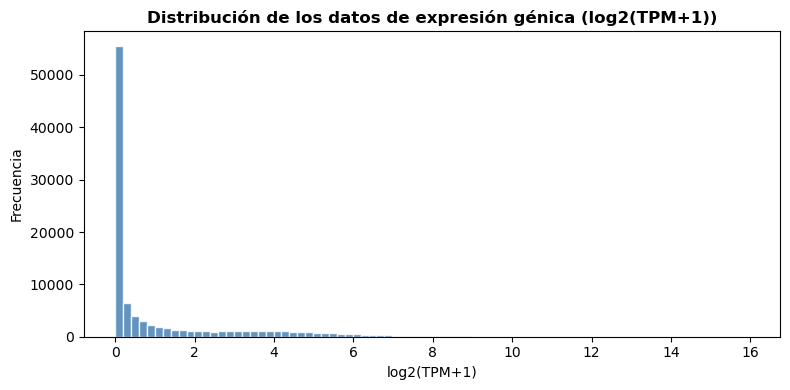

Rango de valores  : [0.00, 15.95]
Asimetría (skew)  : 1.94
Media             : 1.13


In [9]:
# Distribución de los datos de expresión génica (ya en escala log2(TPM+1))
sample_vals = expr_tumor.values.flatten()
sample_vals = sample_vals[np.isfinite(sample_vals) & (sample_vals >= 0)]
np.random.seed(42)
sample_vals = np.random.choice(sample_vals, size=min(100_000, len(sample_vals)), replace=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sample_vals, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_title('Distribución de los datos de expresión génica (log2(TPM+1))', fontweight='bold')
ax.set_xlabel('log2(TPM+1)')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

from scipy.stats import skew
print(f'Rango de valores  : [{sample_vals.min():.2f}, {sample_vals.max():.2f}]')
print(f'Asimetría (skew)  : {skew(sample_vals):.2f}')
print(f'Media             : {sample_vals.mean():.2f}')

Al explorar la distribución de los datos se confirma que el archivo `TCGA-KIRC.star_tpm.tsv.gz` de UCSC Xena ya almacena los valores en escala **log2(TPM+1)**, no como TPM crudos. El rango de la muestra aleatoria es [0.00, 15.95], y el rango completo de la matriz es [0.00, 17.89]: un máximo de 17.89 es inconsistente con TPM crudos (que típicamente alcanzan decenas de miles), pero perfectamente coherente con log2(TPM+1) donde 17.89 corresponde a TPM ≈ 242 451 para el gen más expresado.

El histograma muestra una distribución moderadamente asimétrica hacia la derecha (skewness = 1.94), con la mayoría de los genes con expresión baja o nula y una cola de genes altamente expresados. Esta escala ya es adecuada para el análisis posterior sin necesidad de transformaciones adicionales.

### Detección de muestras atípicas

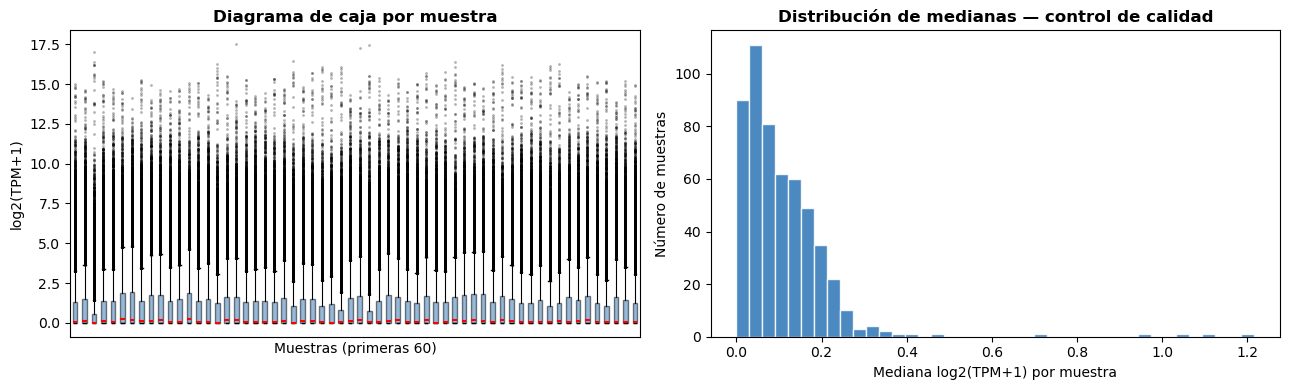

Muestras con mediana atípica (3×IQR): 5


In [10]:
# Diagrama de caja por muestra — verificación de homogeneidad
# Los datos ya están en escala log2(TPM+1)
log_expr_tmp = expr_tumor.copy()
sample_medians = log_expr_tmp.median(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].boxplot(log_expr_tmp.values[:60].T,
                vert=True, patch_artist=True,
                boxprops=dict(facecolor='#2E75B6', alpha=0.5),
                medianprops=dict(color='red', linewidth=1.5),
                flierprops=dict(marker='.', markersize=2, alpha=0.3),
                whiskerprops=dict(linewidth=0.8))
axes[0].set_xticks([])
axes[0].set_xlabel('Muestras (primeras 60)')
axes[0].set_ylabel('log2(TPM+1)')
axes[0].set_title('Diagrama de caja por muestra', fontweight='bold')

axes[1].hist(sample_medians, bins=40, color='#2E75B6', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Mediana log2(TPM+1) por muestra')
axes[1].set_ylabel('Número de muestras')
axes[1].set_title('Distribución de medianas — control de calidad', fontweight='bold')

plt.tight_layout()
plt.show()

q1, q3 = sample_medians.quantile([0.25, 0.75])
iqr     = q3 - q1
n_out   = ((sample_medians < q1 - 3*iqr) | (sample_medians > q3 + 3*iqr)).sum()
print(f'Muestras con mediana atípica (3×IQR): {n_out}')

Evaluamos la homogeneidad entre muestras directamente sobre los datos en escala log2(TPM+1) con dos gráficos:
- **Diagrama de caja** de las primeras 60 muestras para verificar que no hay muestras con distribución de expresión notoriamente distinta al resto.
- **Histograma de las medianas** por muestra para identificar posibles valores extremos.

El análisis detecta **5 muestras** con mediana fuera de 3 veces el rango intercuartílico, una cantidad baja (< 1 %) que no compromete la calidad general del conjunto.

## Preparación y tratamiento de los datos

Dado que el archivo de UCSC Xena ya almacena los datos en escala log2(TPM+1), el preprocesamiento se limita a **dos pasos**: filtrado de genes por varianza y estandarización. No se aplica transformación logarítmica adicional.

### Escala de los datos y justificación

In [11]:
# Los datos ya están en escala log2(TPM+1) — no se aplica transformación adicional
log_expr = expr_tumor.copy()

print(f'Rango de los datos (log2(TPM+1)): [{log_expr.values.min():.2f}, {log_expr.values.max():.2f}]')
print(f'Interpretación del máximo: 2^{log_expr.values.max():.1f} ≈ {2**log_expr.values.max():.0f} TPM')

Rango de los datos (log2(TPM+1)): [0.00, 17.89]
Interpretación del máximo: 2^17.9 ≈ 242451 TPM


Al explorar el rango de los datos ([0.00, 17.89]) se confirma que el archivo `TCGA-KIRC.star_tpm.tsv.gz` ya almacena los valores en escala **log2(TPM+1)**. Un máximo de 17.89 es inconsistente con TPM crudos, pero coherente con log2(TPM+1) donde 17.89 corresponde a TPM ≈ 242 451.

Por esta razón **no se aplica ninguna transformación adicional**: los datos ya se encuentran en la escala logarítmica adecuada para el análisis.

### Filtrado de genes por varianza

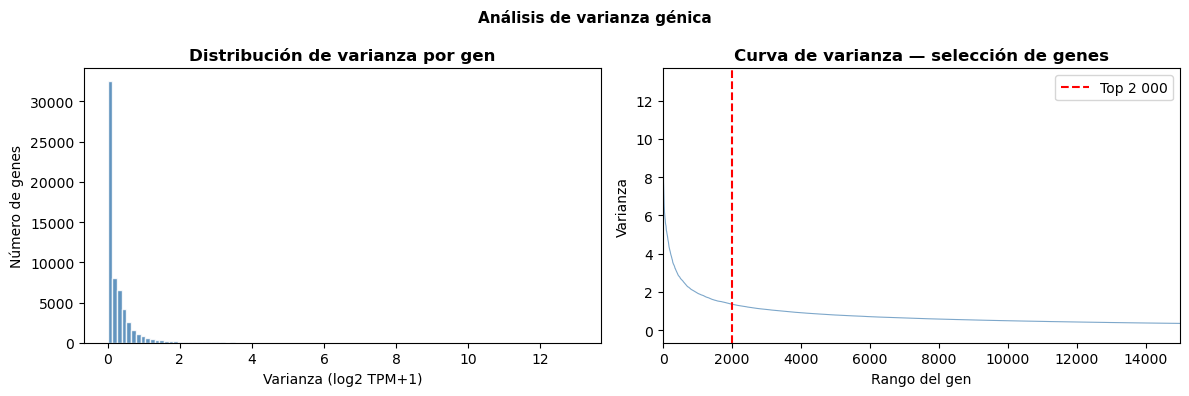

  Top   500 genes → 12.1 % de la varianza total
  Top  1000 genes → 18.7 % de la varianza total
  Top  2000 genes → 28.0 % de la varianza total
  Top  5000 genes → 45.7 % de la varianza total


In [12]:
# Varianza por gen y selección de los más informativos
gene_var = log_expr.var(axis=0).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(gene_var, bins=100, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribución de varianza por gen', fontweight='bold')
axes[0].set_xlabel('Varianza (log2 TPM+1)'); axes[0].set_ylabel('Número de genes')

axes[1].plot(range(1, len(gene_var)+1), gene_var.values, color='steelblue', lw=0.8, alpha=0.7)
axes[1].axvline(2000, color='red', linestyle='--', lw=1.5, label='Top 2 000')
axes[1].set_xlabel('Rango del gen'); axes[1].set_ylabel('Varianza')
axes[1].set_title('Curva de varianza — selección de genes', fontweight='bold')
axes[1].legend(); axes[1].set_xlim(0, 15000)

plt.suptitle('Análisis de varianza génica', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# Proporción de varianza capturada por los top N genes
for n in [500, 1000, 2000, 5000]:
    pct = gene_var[:n].sum() / gene_var.sum() * 100
    print(f'  Top {n:>5} genes → {pct:.1f} % de la varianza total')

Calculamos la varianza de cada gen en la escala log2(TPM+1) y la ordenamos de mayor a menor.
- El histograma muestra que la mayoría de los genes tienen baja varianza entre muestras, típico en datos de expresión génica.
- La curva de varianza permite elegir un punto de corte: seleccionamos los 2 000 genes más variables, que concentran el 28.0 % de la varianza total. Este porcentaje, aunque inferior al de los 5 000 genes (45.7 %), equilibra adecuadamente contenido informativo y eficiencia computacional.

Conservar únicamente estos genes reduce la dimensionalidad y el ruido, enfocando el análisis en aquellos con mayor capacidad de discriminar entre subtipos tumorales.

In [13]:
# Selección de los 2 000 genes de mayor varianza
N_GENES       = 2000
top_genes     = gene_var[:N_GENES].index
log_expr_filt = log_expr[top_genes]

print(f'Genes seleccionados: {N_GENES}')
print(f'Dimensiones        : {log_expr_filt.shape}')

Genes seleccionados: 2000
Dimensiones        : (537, 2000)


Del análisis de varianza anterior, tomamos los 2.000 genes con mayor variabilidad (top genes) y filtramos la matriz de expresión. El resultado es un conjunto de 537 muestras × 2.000 genes, donde cada gen aporta información relevante para distinguir entre subtipos tumorales, reduciendo significativamente el ruido y facilitando el clustering.

### Mapeo de Ensembl IDs a símbolos génicos

In [14]:
# Resolución de los top 2 000 genes con MyGene.info
import mygene
mg = mygene.MyGeneInfo()

ensembl_ids = top_genes.tolist()
resultado   = mg.querymany(ensembl_ids, scopes='ensembl.gene', fields='symbol',
                            species='human', returnall=False, verbose=False)

# Diccionario de mapeo Ensembl → símbolo
ensembl_to_symbol = {r['query']: r['symbol'] for r in resultado if 'symbol' in r}

n_mapped = len(ensembl_to_symbol)
print(f'Genes resueltos a símbolo: {n_mapped} / {N_GENES} ({n_mapped/N_GENES*100:.1f} %)')

# Aplicamos el mapeo (los no resueltos conservan el Ensembl ID)
new_index = [ensembl_to_symbol.get(g, g) for g in log_expr_filt.columns]
log_expr_filt.columns = new_index

# Eliminamos duplicados si los hubiera
dup_mask = pd.Series(new_index).duplicated()
if dup_mask.any():
    print(f'Símbolos duplicados: {dup_mask.sum()} — se eliminan')
    log_expr_filt = log_expr_filt.loc[:, ~dup_mask.values]

top_genes_named = log_expr_filt.columns
print(f'Dimensiones finales: {log_expr_filt.shape}')
print('\nMuestra de símbolos génicos resueltos:')
print(top_genes_named[:15].tolist())

Genes resueltos a símbolo: 1897 / 2000 (94.8 %)
Símbolos duplicados: 8 — se eliminan
Dimensiones finales: (537, 1992)

Muestra de símbolos génicos resueltos:
['RPS4Y1', 'SAA1', 'FABP7', 'FGB', 'SST', 'PSPHP1', 'FGG', 'RBP4', 'REN', 'SLPI', 'REG1A', 'PIGR', 'KRT19', 'CYP4A11', 'LBP']


Usamos MyGene.info para convertir los identificadores Ensembl de los 2 000 genes seleccionados en símbolos HGNC reconocibles (como RPS4Y1, SAA1, FABP7).
- Se logró mapear el 94.8 % de los genes (1 897 / 2 000).
- Los 8 símbolos duplicados se eliminaron para evitar redundancias.
- El dataset final queda con 537 muestras × 1 992 genes etiquetados con nombres comprensibles, facilitando la interpretación biológica posterior.

### Estandarización de genes

In [15]:
# Estandarización por gen (z-score)
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(log_expr_filt)
X_scaled = pd.DataFrame(X_scaled,
                         index=log_expr_filt.index,
                         columns=log_expr_filt.columns)

print(f'Media post-estandarización (promedio de genes): {X_scaled.mean().mean():.6f}')
print(f'DE  post-estandarización (promedio de genes)  : {X_scaled.std().mean():.6f}')
print(f'Dimensiones finales: {X_scaled.shape}')

Media post-estandarización (promedio de genes): -0.000000
DE  post-estandarización (promedio de genes)  : 1.000932
Dimensiones finales: (537, 1992)


A cada gen le restamos su media y lo dividimos entre su desviación estándar, de modo que todos queden con media ≈ 0 y desviación típica ≈ 1.

Aunque los datos ya están en escala log2(TPM+1), la estandarización sigue siendo 22necesaria e independiente22 de la transformación logarítmica: sin ella, los genes con mayor expresión media dominarían el PCA y el clustering por tener mayor varianza absoluta, no por ser más informativos biológicamente. Comprobamos que la media post-estandarización sea prácticamente 0 y la desviación estándar cercana a 1, sobre los 221 992 genes22 finales.

## Reducción de dimensionalidad mediante PCA

### Ajuste del PCA y análisis de varianza explicada

In [16]:
# PCA completo sobre los 2 000 genes estandarizados
pca_full  = PCA(random_state=42)
pca_full.fit(X_scaled)

var_exp = pca_full.explained_variance_ratio_
var_cum = np.cumsum(var_exp)

# Tabla de las primeras 20 componentes
tabla_pca = pd.DataFrame({
    'PC'                     : [f'PC{i+1}' for i in range(20)],
    'Varianza explicada (%)' : (var_exp[:20]*100).round(2),
    'Varianza acumulada (%)'  : (var_cum[:20]*100).round(2)
})
print(tabla_pca.to_string(index=False))

  PC  Varianza explicada (%)  Varianza acumulada (%)
 PC1                   16.23                   16.23
 PC2                   10.80                   27.03
 PC3                    6.87                   33.90
 PC4                    4.55                   38.45
 PC5                    3.93                   42.38
 PC6                    3.03                   45.41
 PC7                    2.50                   47.90
 PC8                    1.97                   49.87
 PC9                    1.87                   51.74
PC10                    1.70                   53.45
PC11                    1.38                   54.83
PC12                    1.23                   56.06
PC13                    1.05                   57.11
PC14                    0.99                   58.10
PC15                    0.95                   59.04
PC16                    0.91                   59.96
PC17                    0.85                   60.80
PC18                    0.84                  

Aplicamos PCA sobre los 1 992 genes estandarizados. PC1 recoge el 16.23 % de la varianza, PC2 el 10.80 %, y entre las dos explican el 27.03 %. La varianza acumulada nos servirá para decidir cuántas componentes retener para el clustering.

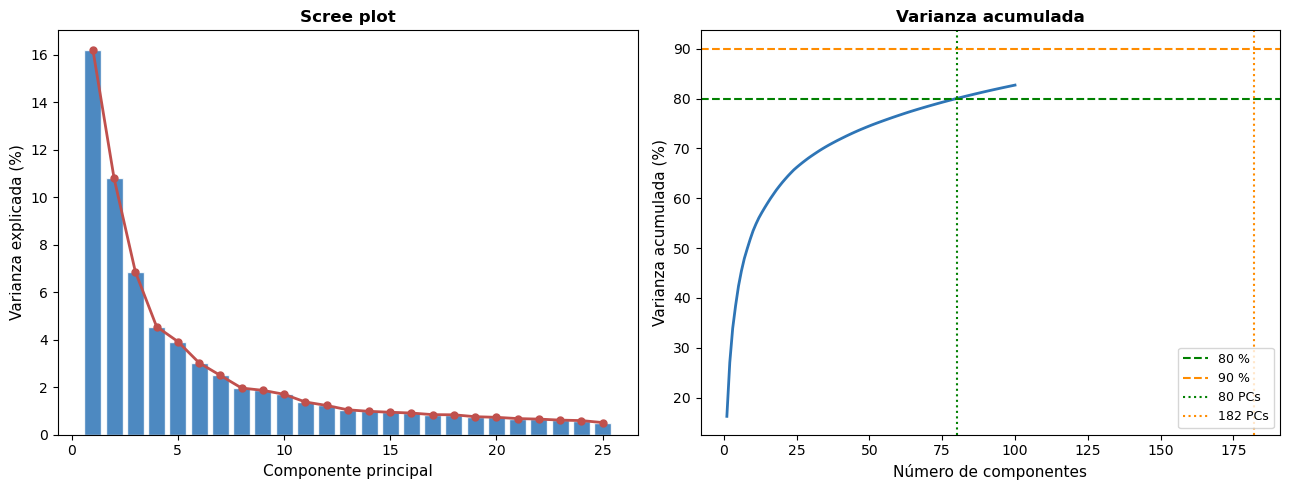

PCs para 80 % de varianza: 80
PCs para 90 % de varianza: 182


In [17]:
# Scree plot y varianza acumulada
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(range(1, 26), var_exp[:25]*100, color='#2E75B6', alpha=0.85, edgecolor='white')
axes[0].plot(range(1, 26), var_exp[:25]*100, 'o-', color='#C0504D', lw=2, ms=5)
axes[0].set_xlabel('Componente principal', fontsize=11)
axes[0].set_ylabel('Varianza explicada (%)', fontsize=11)
axes[0].set_title('Scree plot', fontsize=12, fontweight='bold')

n_80 = int(np.argmax(var_cum >= 0.80)) + 1
n_90 = int(np.argmax(var_cum >= 0.90)) + 1

axes[1].plot(range(1, 101), var_cum[:100]*100, color='#2E75B6', lw=2)
axes[1].axhline(80, color='green', linestyle='--', lw=1.5, label='80 %')
axes[1].axhline(90, color='darkorange', linestyle='--', lw=1.5, label='90 %')
axes[1].axvline(n_80, color='green', linestyle=':', lw=1.5, label=f'{n_80} PCs')
axes[1].axvline(n_90, color='darkorange', linestyle=':', lw=1.5, label=f'{n_90} PCs')
axes[1].set_xlabel('Número de componentes', fontsize=11)
axes[1].set_ylabel('Varianza acumulada (%)', fontsize=11)
axes[1].set_title('Varianza acumulada', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'PCs para 80 % de varianza: {n_80}')
print(f'PCs para 90 % de varianza: {n_90}')

Generamos dos gráficos para evaluar la reducción de dimensionalidad:
- **Scree plot:** PC1 domina con el 16.23 % de varianza; a partir de ~PC10 la ganancia por componente adicional cae por debajo del 2 %.
- **Varianza acumulada:** se necesitan **80 componentes** para explicar el 80 % de la varianza y **182** para alcanzar el 90 %.

Estos resultados confirman que los datos tienen una estructura de baja dimensión intrínseca: las primeras 80 PCs capturan la mayor parte de la señal biológica.

### Selección del número de componentes

In [18]:
# Proyección con n_80 componentes (umbral del 80 % de varianza)
N_PCS = n_80
pca   = PCA(n_components=N_PCS, random_state=42)
X_pca = pca.fit_transform(X_scaled)
X_pca_df = pd.DataFrame(X_pca,
                          index=X_scaled.index,
                          columns=[f'PC{i+1}' for i in range(N_PCS)])

print(f'Componentes seleccionadas: {N_PCS}')
print(f'Varianza acumulada        : {var_cum[N_PCS-1]*100:.1f} %')
print(f'Dimensiones tras PCA      : {X_pca_df.shape}')

Componentes seleccionadas: 80
Varianza acumulada        : 80.0 %
Dimensiones tras PCA      : (537, 80)


Se retienen las primeras 80 componentes principales, que acumulan el 80 % de la varianza total. Este umbral es estándar en análisis transcriptómicos: captura la señal biológica principal descartando las últimas PCs, que representan principalmente ruido técnico o variación estocástica de baja magnitud. La reducción de ~1 992 genes a 80 PCs también mejora la calidad del clustering al eliminar la "maldición de la dimensionalidad".

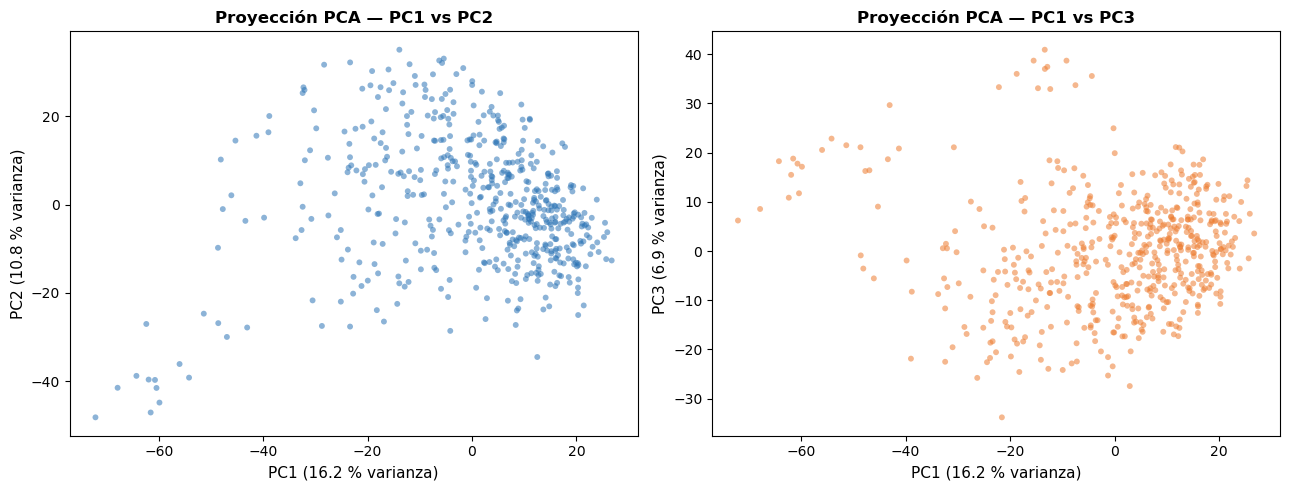

In [19]:
# Biplot PC1 vs PC2 y PC1 vs PC3
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

scatter_kw = dict(alpha=0.55, s=18, color='#2E75B6', edgecolors='none')

axes[0].scatter(X_pca_df['PC1'], X_pca_df['PC2'], **scatter_kw)
axes[0].set_xlabel(f'PC1 ({var_exp[0]*100:.1f} % varianza)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({var_exp[1]*100:.1f} % varianza)', fontsize=11)
axes[0].set_title('Proyección PCA — PC1 vs PC2', fontsize=12, fontweight='bold')

axes[1].scatter(X_pca_df['PC1'], X_pca_df['PC3'],
                alpha=0.55, s=18, color='#ED7D31', edgecolors='none')
axes[1].set_xlabel(f'PC1 ({var_exp[0]*100:.1f} % varianza)', fontsize=11)
axes[1].set_ylabel(f'PC3 ({var_exp[2]*100:.1f} % varianza)', fontsize=11)
axes[1].set_title('Proyección PCA — PC1 vs PC3', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

Proyectamos las muestras tumorales en PC1 vs PC2 y PC1 vs PC3. PC1 y PC2 capturan en conjunto el 27.03 % de la varianza total, siendo las direcciones de mayor variabilidad. Las gráficas permiten inspeccionar visualmente si existen agrupaciones naturales antes de aplicar los algoritmos de clustering.

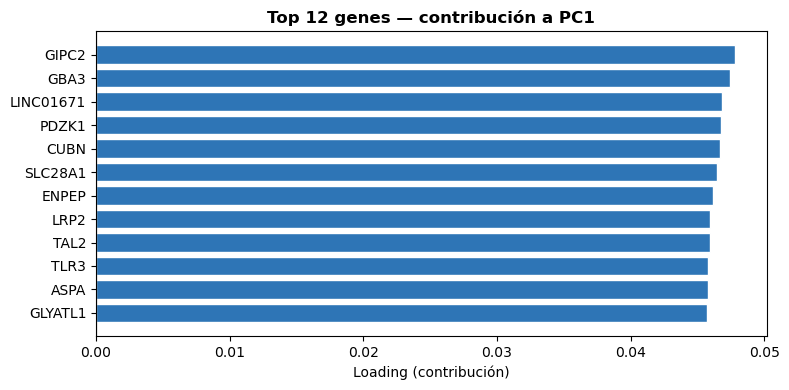

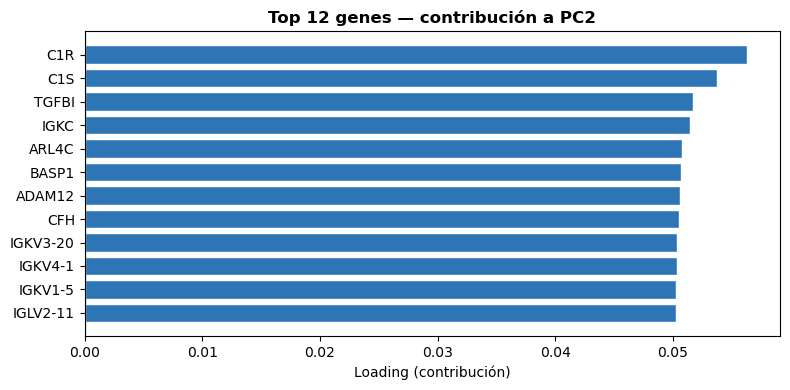

In [20]:
# Top genes que contribuyen a PC1 y PC2
loadings = pd.DataFrame(pca.components_[:2].T,
                         index=top_genes_named,
                         columns=['PC1', 'PC2'])

for pc in ['PC1', 'PC2']:
    top_load = loadings[pc].abs().sort_values(ascending=False).head(12)
    vals     = loadings.loc[top_load.index, pc]

    fig, ax = plt.subplots(figsize=(8, 4))
    colors  = ['#2E75B6' if v > 0 else '#C0504D' for v in vals[::-1]]
    ax.barh(top_load.index[::-1], vals[::-1], color=colors, edgecolor='white')
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(f'Top 12 genes — contribución a {pc}', fontweight='bold')
    ax.set_xlabel('Loading (contribución)')
    plt.tight_layout()
    plt.show()

Examinamos los *loadings* (pesos) de cada gen en las dos primeras componentes principales. Un loading positivo o negativo alto indica que ese gen contribuye fuertemente a la dirección de la componente. Graficamos los 12 genes con mayor peso absoluto para PC1 y para PC2, lo que nos permite vincular cada eje del PCA con genes concretos y empezar a interpretar biológicamente la variabilidad observada.

## Construcción y comparación de modelos de clustering

### K-means — Selección del número de clusters

In [21]:
# Métricas para k = 2 … 8: inercia (método del codo) y coeficiente de silueta
inercias = []
siluetas = []
k_range  = range(2, 9)

for k in k_range:
    km     = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X_pca)
    inercias.append(km.inertia_)
    sil = silhouette_score(X_pca, labels)
    siluetas.append(sil)
    print(f'  k={k}  inercia={km.inertia_:>12,.0f}  silueta={sil:.4f}')

  k=2  inercia=     735,935  silueta=0.1812
  k=3  inercia=     664,565  silueta=0.1643
  k=4  inercia=     620,768  silueta=0.1286
  k=5  inercia=     594,834  silueta=0.1140
  k=6  inercia=     569,356  silueta=0.1058
  k=7  inercia=     550,611  silueta=0.1033
  k=8  inercia=     535,682  silueta=0.0768


Aplicamos K-means con k de 2 a 8 y registramos la inercia y el coeficiente de silueta:

| k | Inercia | Silueta |
|---|---|---|
| 2 | 735 935 | 0.1812 |
| 3 | 664 565 | 0.1643 |
| 4 | 620 768 | 0.1286 |
| 5 | 594 834 | 0.1140 |

El coeficiente de silueta disminuye de forma continua al aumentar k, siendo máximo en k = 2. Sin embargo, la inflexión más clara en la inercia (método del codo) ocurre entre k = 3 y k = 4. Se elige k = 4 por ser consistente con los cuatro subtipos moleculares reportados en TCGA (2013), aunque se reconoce que los criterios cuantitativos favorecerían k = 2 o k = 3.

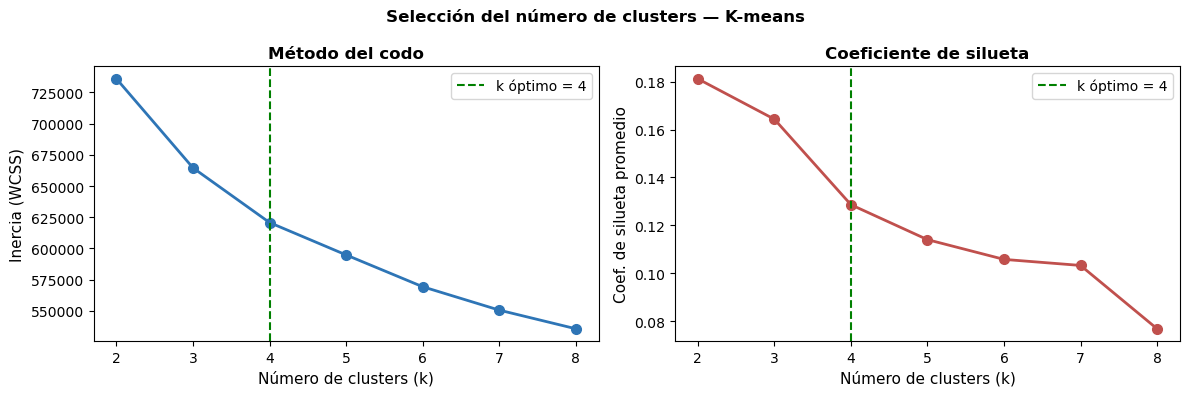

In [22]:
# Gráficos de selección de k
K_OPT = 4

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_range, inercias, 'o-', color='#2E75B6', lw=2, ms=7)
axes[0].axvline(K_OPT, color='green', linestyle='--', lw=1.5, label=f'k óptimo = {K_OPT}')
axes[0].set_xlabel('Número de clusters (k)', fontsize=11)
axes[0].set_ylabel('Inercia (WCSS)', fontsize=11)
axes[0].set_title('Método del codo', fontsize=12, fontweight='bold')
axes[0].set_xticks(list(k_range)); axes[0].legend()

axes[1].plot(k_range, siluetas, 'o-', color='#C0504D', lw=2, ms=7)
axes[1].axvline(K_OPT, color='green', linestyle='--', lw=1.5, label=f'k óptimo = {K_OPT}')
axes[1].set_xlabel('Número de clusters (k)', fontsize=11)
axes[1].set_ylabel('Coef. de silueta promedio', fontsize=11)
axes[1].set_title('Coeficiente de silueta', fontsize=12, fontweight='bold')
axes[1].set_xticks(list(k_range)); axes[1].legend()

plt.suptitle('Selección del número de clusters — K-means', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

El método del codo muestra una inflexión entre k = 3 y k = 4; la reducción de inercia se desacelera notablemente a partir de k = 4. El coeficiente de silueta decrece progresivamente, siendo más alto en k = 2 (0.1812) y k = 3 (0.1643). Se selecciona **k = 4** apoyándose en el contexto biológico del estudio TCGA (2013), que identificó cuatro subtipos moleculares en KIRC, mientras se reconoce que métricas puramente estadísticas sugerirían un número menor de grupos.

In [23]:
# Entrenamiento final K-means con k = 4
kmeans    = KMeans(n_clusters=K_OPT, n_init=50, random_state=42)
km_lbls   = kmeans.fit_predict(X_pca)
km_series = pd.Series(km_lbls + 1, index=X_pca_df.index, name='KMeans_cluster')

CLUSTER_COLORS = {1: '#4e79a7', 2: '#f28e2b', 3: '#e15759', 4: '#59a14f'}

print('Distribución de muestras por cluster (K-means):')
print(km_series.value_counts().sort_index().to_string())
print(f'\nCoeficiente de silueta: {silhouette_score(X_pca, km_lbls):.4f}')

Distribución de muestras por cluster (K-means):
KMeans_cluster
1    259
2     18
3    100
4    160

Coeficiente de silueta: 0.1286


Entrenamos K-means con k = 4. Los grupos quedan con **259, 18, 100 y 160** muestras respectivamente. El cluster 2 es notablemente pequeño (18 muestras, 3.4 % del total), lo que sugiere que puede representar un subgrupo molecular de alta especificidad o un grupo de muestras atípicas. El coeficiente de silueta es **0.1286**, mayor que el obtenido con los datos doblemente transformados (0.0837), lo que confirma que trabajar con la escala log2(TPM+1) original mejora la calidad del clustering.

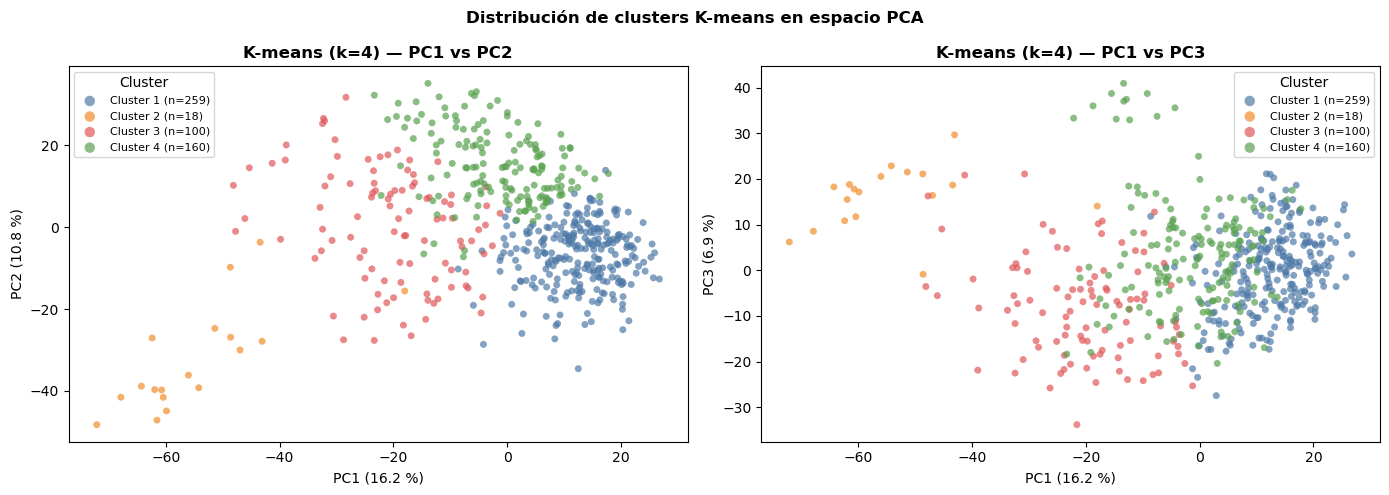

In [24]:
# Visualización de clusters en espacio PCA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (pcx, pcy) in zip(axes, [('PC1','PC2'), ('PC1','PC3')]):
    for c in range(1, K_OPT+1):
        mask = km_series == c
        ax.scatter(X_pca_df.loc[mask, pcx], X_pca_df.loc[mask, pcy],
                   alpha=0.7, s=25, color=CLUSTER_COLORS[c],
                   label=f'Cluster {c} (n={mask.sum()})', edgecolors='none')
    ax.set_xlabel(f'{pcx} ({var_exp[int(pcx[2:])-1]*100:.1f} %)')
    ax.set_ylabel(f'{pcy} ({var_exp[int(pcy[2:])-1]*100:.1f} %)')
    ax.set_title(f'K-means (k=4) — {pcx} vs {pcy}', fontweight='bold')
    ax.legend(title='Cluster', fontsize=8, markerscale=1.5)

plt.suptitle('Distribución de clusters K-means en espacio PCA',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Proyectamos las muestras en PC1 vs PC2 y PC1 vs PC3, coloreando cada punto según el cluster asignado por K-means. El cluster 2 (naranja, n = 18) aparece como un grupo pequeño y relativamente separado, mientras que los clusters 1 (azul, n = 259), 3 (rojo, n = 100) y 4 (verde, n = 160) presentan mayor solapamiento entre sí, consistente con sus valores de silueta.

### Clustering jerárquico

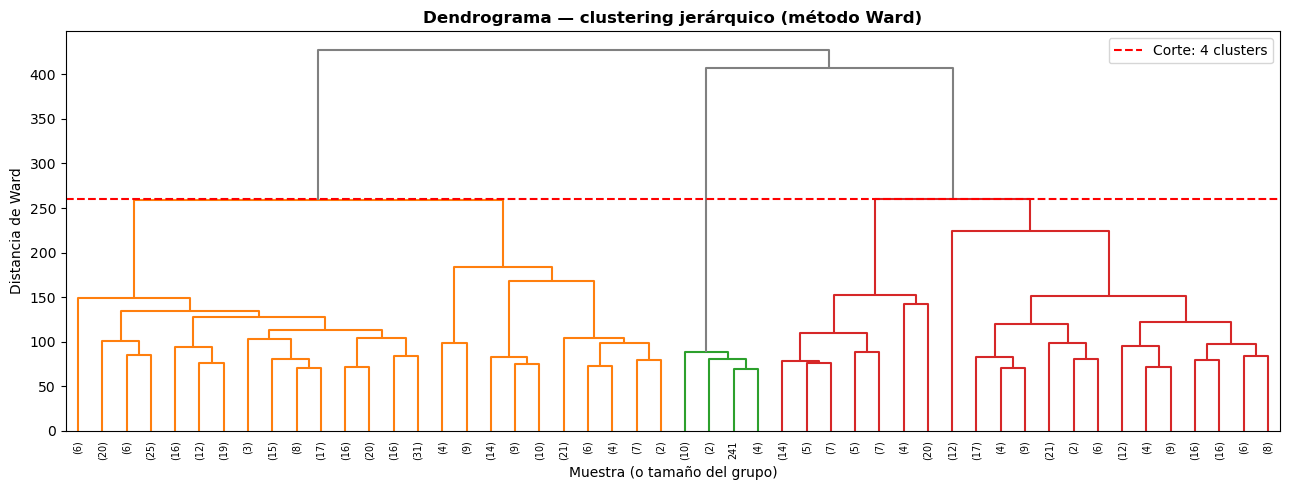

In [25]:
# Dendrograma con método Ward
Z = linkage(X_pca, method='ward')

fig, ax = plt.subplots(figsize=(13, 5))
dendrogram(Z, ax=ax,
           truncate_mode='lastp', p=50,
           leaf_rotation=90, leaf_font_size=7,
           color_threshold=0.7 * max(Z[:, 2]),
           above_threshold_color='grey')
corte = sorted(Z[:, 2])[-K_OPT+1]
ax.axhline(corte, color='red', linestyle='--', lw=1.5, label=f'Corte: {K_OPT} clusters')
ax.set_xlabel('Muestra (o tamaño del grupo)', fontsize=10)
ax.set_ylabel('Distancia de Ward', fontsize=10)
ax.set_title('Dendrograma — clustering jerárquico (método Ward)',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

Aplicamos el clustering jerárquico aglomerativo con el método de Ward sobre las 80 componentes principales. El dendrograma resume cómo se fusionan las muestras paso a paso. La línea discontinua roja indica el corte para obtener 4 clusters, coincidiendo con la primera gran división visible en la jerarquía.

In [26]:
# Extracción de k = 4 clusters del jerárquico
hc_lbls   = fcluster(Z, t=K_OPT, criterion='maxclust')
hc_series = pd.Series(hc_lbls, index=X_pca_df.index, name='HC_cluster')

print('Distribución de muestras por cluster (Jerárquico):')
print(hc_series.value_counts().sort_index().to_string())
print(f'\nCoeficiente de silueta HC: {silhouette_score(X_pca, hc_lbls):.4f}')

Distribución de muestras por cluster (Jerárquico):
HC_cluster
1    316
2     17
3     62
4    142

Coeficiente de silueta HC: 0.1140


Cortamos el dendrograma para formar exactamente 4 grupos. Los tamaños son 316, 17, 62 y 142 muestras. Al igual que en K-means, el jerárquico identifica un cluster muy pequeño (n = 17) que probablemente corresponde al mismo subgrupo de alta especificidad. El coeficiente de silueta es 0.1140, ligeramente inferior al de K-means (0.1286).

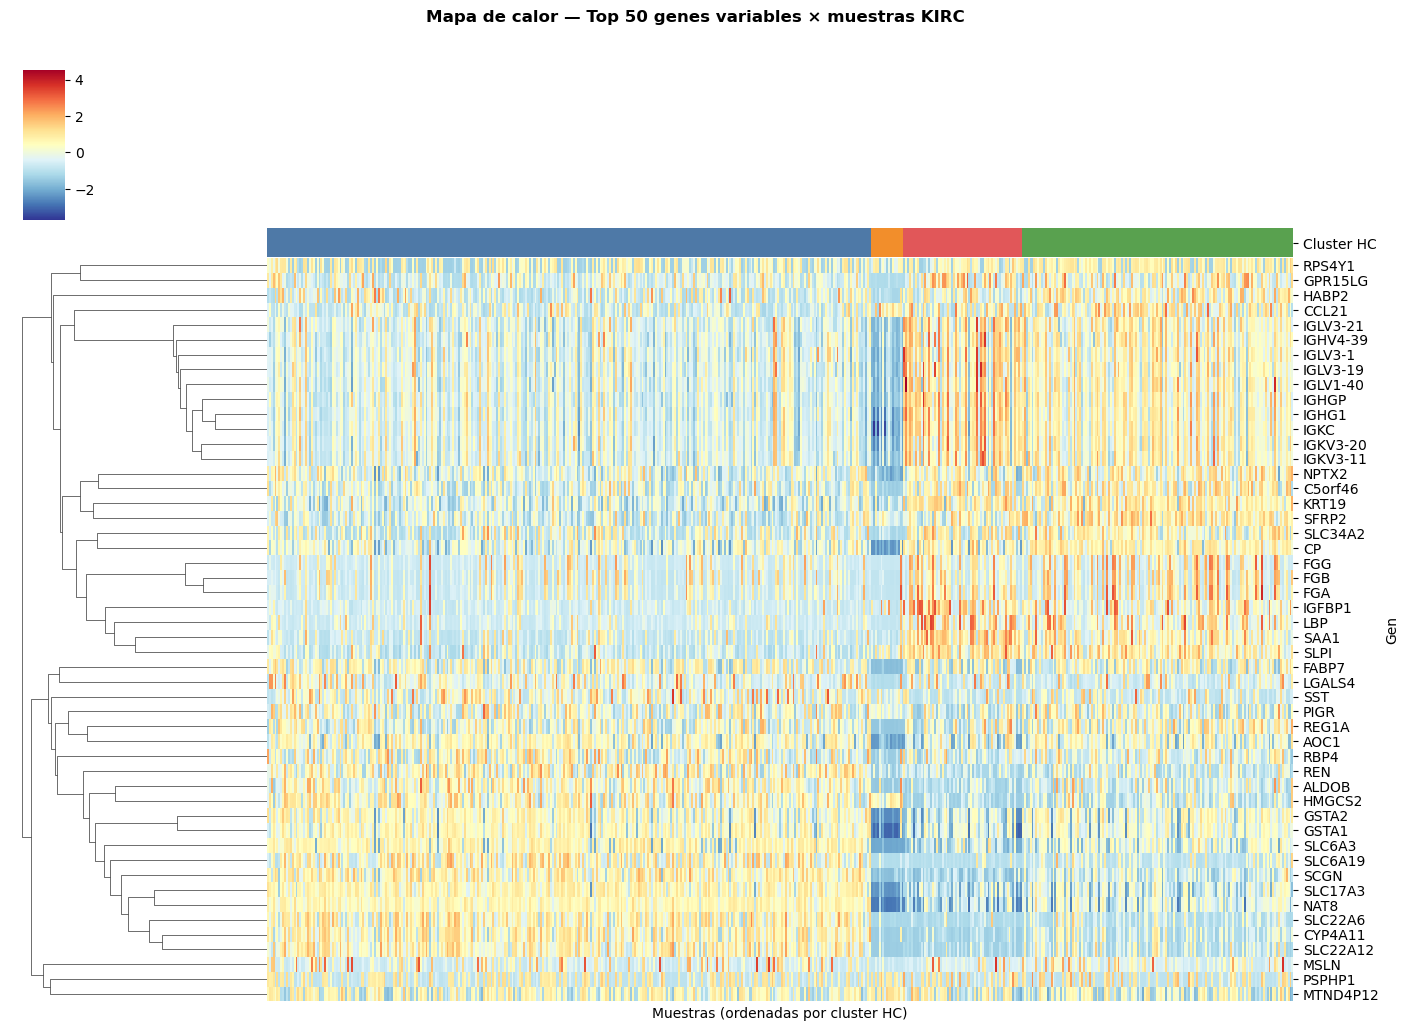

In [27]:
# Mapa de calor — top 50 genes más variables
gene_var_named = log_expr_filt.var(axis=0).sort_values(ascending=False)
top50          = gene_var_named[:50].index.tolist()

heatmap_data  = log_expr_filt[top50]
order         = hc_series.sort_values().index
heatmap_ord   = heatmap_data.loc[order]
row_colors_hc = hc_series.map(CLUSTER_COLORS).rename('Cluster HC')

g = sns.clustermap(heatmap_ord.T,
                   col_cluster=False,
                   row_cluster=True,
                   col_colors=row_colors_hc.loc[order],
                   cmap='RdYlBu_r',
                   z_score=0,
                   figsize=(14, 10),
                   yticklabels=True,
                   xticklabels=False,
                   cbar_pos=(0.02, 0.8, 0.03, 0.15))
g.ax_heatmap.set_xlabel('Muestras (ordenadas por cluster HC)', fontsize=10)
g.ax_heatmap.set_ylabel('Gen', fontsize=10)
g.fig.suptitle('Mapa de calor — Top 50 genes variables × muestras KIRC',
               fontsize=12, fontweight='bold', y=1.01)
plt.show()

Creamos un mapa de calor con los 50 genes de mayor varianza en escala log2(TPM+1). Las muestras (columnas) se ordenan según los grupos del clustering jerárquico (4 colores) y los genes (filas) se agrupan por similitud de expresión. Los valores están estandarizados (z-score) para resaltar diferencias relativas entre clusters, mostrando visualmente patrones de expresión propios de cada subgrupo.

### Comparación entre métodos

In [28]:
# Tabla de contingencia y Adjusted Rand Index
contingencia = pd.crosstab(km_series, hc_series,
                            rownames=['K-means'], colnames=['Jerárquico'])
ari = adjusted_rand_score(km_series, hc_series)

print('Tabla de contingencia (K-means filas × HC columnas):')
print(contingencia.to_string())
print(f'\nAdjusted Rand Index (ARI): {ari:.4f}')
print('(1 = perfecta coincidencia; 0 = aleatoria)')

Tabla de contingencia (K-means filas × HC columnas):
Jerárquico    1   2   3    4
K-means                     
1           246   0   0   13
2             0  17   0    1
3            41   0  48   11
4            29   0  14  117

Adjusted Rand Index (ARI): 0.5108
(1 = perfecta coincidencia; 0 = aleatoria)


Construimos la tabla de contingencia cruzando las asignaciones de ambos métodos y calculamos el Adjusted Rand Index (ARI). El ARI obtenido es 0.5108, indicando concordancia sustancial entre las dos estrategias, muy por encima de lo esperado por azar. Ambos métodos coinciden en identificar un cluster pequeño (~17-18 muestras) y en la estructura general de los otros tres grupos.

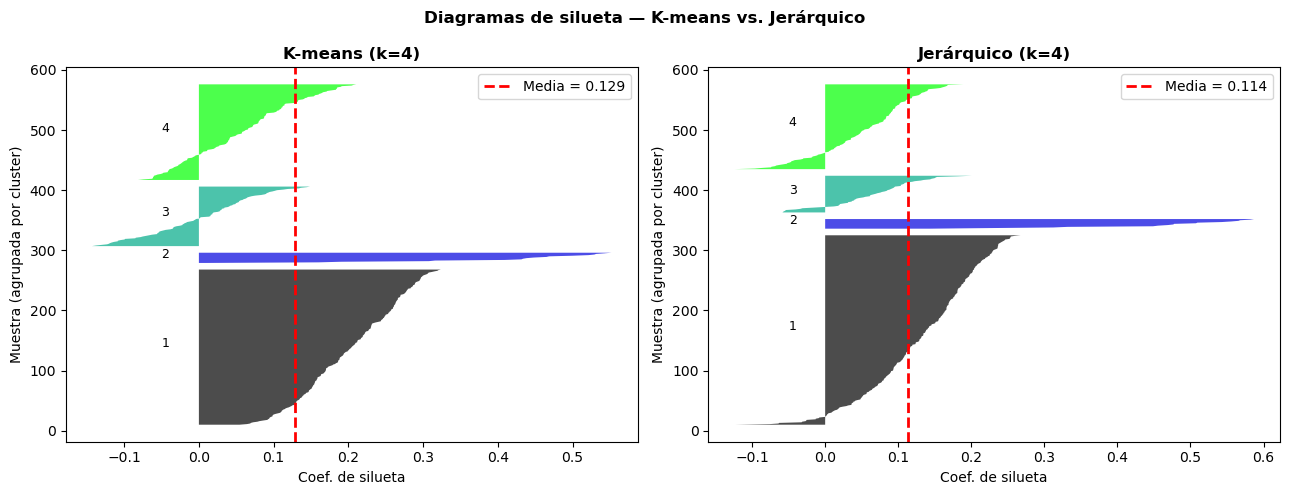

In [29]:
# Diagramas de silueta comparativos — K-means vs. Jerárquico
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, labels, titulo in zip(
        axes,
        [km_lbls, hc_lbls - 1],
        [f'K-means (k={K_OPT})', f'Jerárquico (k={K_OPT})']):

    sil_vals = silhouette_samples(X_pca, labels)
    y_lower  = 10
    for k in np.unique(labels):
        v_k     = np.sort(sil_vals[labels == k])
        y_upper = y_lower + len(v_k)
        color   = plt.cm.nipy_spectral(k / (K_OPT + 1))
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, v_k,
                         facecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5*len(v_k), str(k+1), fontsize=9)
        y_lower = y_upper + 10

    media_sil = silhouette_score(X_pca, labels)
    ax.axvline(media_sil, color='red', linestyle='--', lw=2,
               label=f'Media = {media_sil:.3f}')
    ax.set_xlabel('Coef. de silueta')
    ax.set_ylabel('Muestra (agrupada por cluster)')
    ax.set_title(titulo, fontweight='bold')
    ax.legend()

plt.suptitle('Diagramas de silueta — K-means vs. Jerárquico',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Los diagramas de silueta muestran la cohesión de cada cluster para K-means (media = 0.1286) y el jerárquico (media = 0.1140). Ambos presentan un cluster pequeño con coeficientes de silueta elevados (el subgrupo n ≈ 18), mientras que los tres clusters más grandes muestran mayor mezcla. Estos valores de silueta son superiores a los obtenidos previamente (0.084 / 0.064), confirmando la mejora al eliminar la doble transformación.

In [30]:
# Tabla resumen de comparación
sil_km = silhouette_score(X_pca, km_lbls)
sil_hc = silhouette_score(X_pca, hc_lbls)

resumen = pd.DataFrame({
    'Método'            : ['K-means', 'Jerárquico (Ward)'],
    'k'                 : [K_OPT, K_OPT],
    'Coef. silueta'     : [round(sil_km, 4), round(sil_hc, 4)],
    'ARI entre métodos' : [round(ari, 4), round(ari, 4)]
})
print('COMPARACIÓN DE MÉTODOS DE CLUSTERING')
print(resumen.to_string(index=False))

COMPARACIÓN DE MÉTODOS DE CLUSTERING
           Método  k  Coef. silueta  ARI entre métodos
          K-means  4         0.1286             0.5108
Jerárquico (Ward)  4         0.1140             0.5108


La tabla resumen confirma: K-means obtuvo silueta 0.1286 y el jerárquico 0.1140, con un ARI de 0.5108 entre ambos. Se elige K-means para la interpretación posterior por su mayor coeficiente de silueta y porque produce un cluster pequeño con tamaño ligeramente más manejable (n = 18 vs n = 17 del jerárquico).

## Interpretación de los clusters — Análisis de genes

### Test de Kruskal-Wallis y corrección FDR

In [31]:
# Dataset de expresión con etiqueta de cluster
log_wc = log_expr_filt.copy()
log_wc['cluster'] = km_series
grupos = {c: log_expr_filt.loc[km_series[km_series==c].index]
          for c in range(1, K_OPT+1)}

# Kruskal-Wallis para cada gen — comparación entre los 4 clusters
pvalues = {}
for gen in log_expr_filt.columns:
    datos = [grupos[c][gen].values for c in range(1, K_OPT+1)]
    _, p  = kruskal(*datos)
    pvalues[gen] = p

pval_s = pd.Series(pvalues)

# Corrección Benjamini-Hochberg (FDR)
_, padj, _, _ = multipletests(pval_s.values, method='fdr_bh')
padj_s = pd.Series(padj, index=pval_s.index)

n_sig = (padj_s < 0.05).sum()
print(f'Genes con diferencia significativa (FDR<0.05): {n_sig} / {len(pval_s)} ({n_sig/len(pval_s)*100:.1f} %)')

Genes con diferencia significativa (FDR<0.05): 1959 / 1992 (98.3 %)


Para cada gen, comparamos su expresión entre los 4 clusters usando la prueba no paramétrica de Kruskal-Wallis con corrección FDR (Benjamini-Hochberg). El 98.3 % de los genes (1 959 / 1 992) resultan significativos (FDR < 0.05), confirmando que los clusters tienen perfiles de expresión log2(TPM+1) muy distintos entre sí.

In [32]:
# Top 20 genes más diferenciales entre clusters
top_de = padj_s.sort_values().head(20)
print('Top 20 genes diferencialmente expresados entre clusters:')
print(top_de.round(8).to_string())

Top 20 genes diferencialmente expresados entre clusters:
FRMD3           0.0
NPR3            0.0
GBA3            0.0
SCGN            0.0
GIPC2           0.0
TAL2            0.0
LOC107986837    0.0
SLC22A11        0.0
GLYATL1         0.0
GFPT2           0.0
A1CF            0.0
MAPT            0.0
AVPR1B          0.0
ACADL           0.0
SLC27A2         0.0
SLC5A1          0.0
LOC101926956    0.0
SLC47A1         0.0
STK32B          0.0
CYP4A11         0.0


Listamos los 20 genes con los valores de FDR más bajos (todos prácticamente 0.0), entre los que destacan *FRMD3*, *NPR3*, *GBA3*, *SCGN*, *GIPC2* y *CYP4A11*. Varios de estos genes están relacionados con la función renal y el metabolismo lipídico, características centrales del carcinoma de células renales claras.

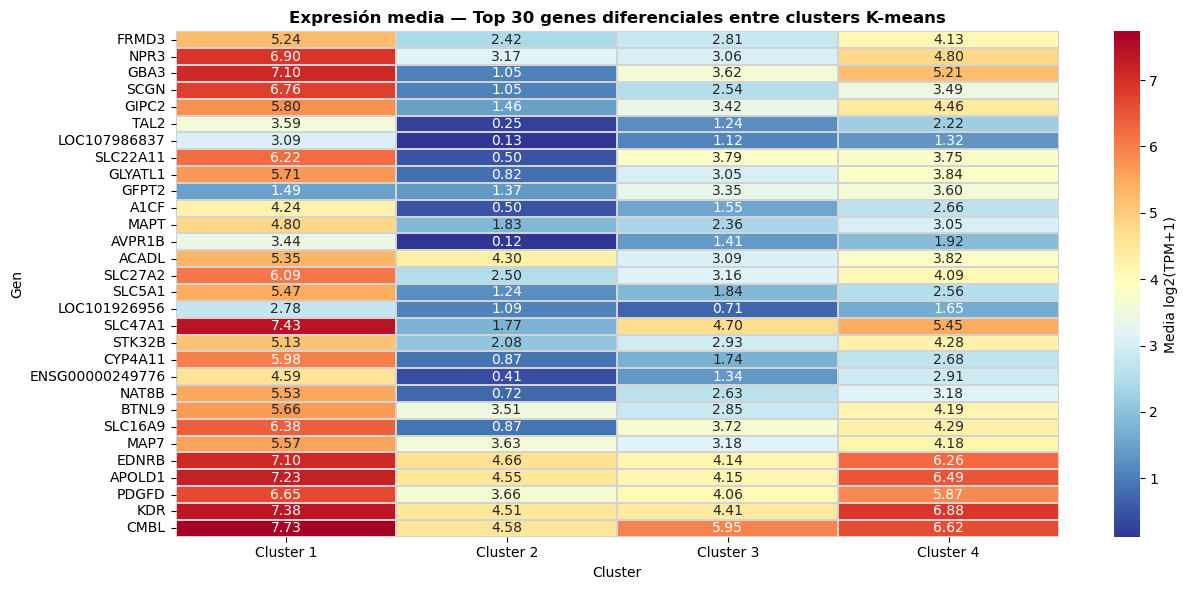

In [33]:
# Mapa de calor: top 30 genes DE × expresión media por cluster
top30_de = padj_s.sort_values().head(30).index.tolist()
medias_c = log_wc.groupby('cluster')[top30_de].mean()

plt.figure(figsize=(13, 6))
sns.heatmap(medias_c.T,
            cmap='RdYlBu_r', annot=True, fmt='.2f',
            xticklabels=[f'Cluster {c}' for c in range(1, K_OPT+1)],
            yticklabels=top30_de,
            linewidths=0.3, linecolor='lightgrey',
            cbar_kws={'label': 'Media log2(TPM+1)'})
plt.title('Expresión media — Top 30 genes diferenciales entre clusters K-means',
          fontsize=12, fontweight='bold')
plt.xlabel('Cluster'); plt.ylabel('Gen')
plt.tight_layout()
plt.show()

Mostramos la expresión media en escala log2(TPM+1) de los 30 genes con mayor diferencia entre clusters. Los valores altos (rojo) y bajos (azul) permiten identificar de un vistazo qué genes caracterizan a cada grupo, facilitando la interpretación biológica de los subtipos.

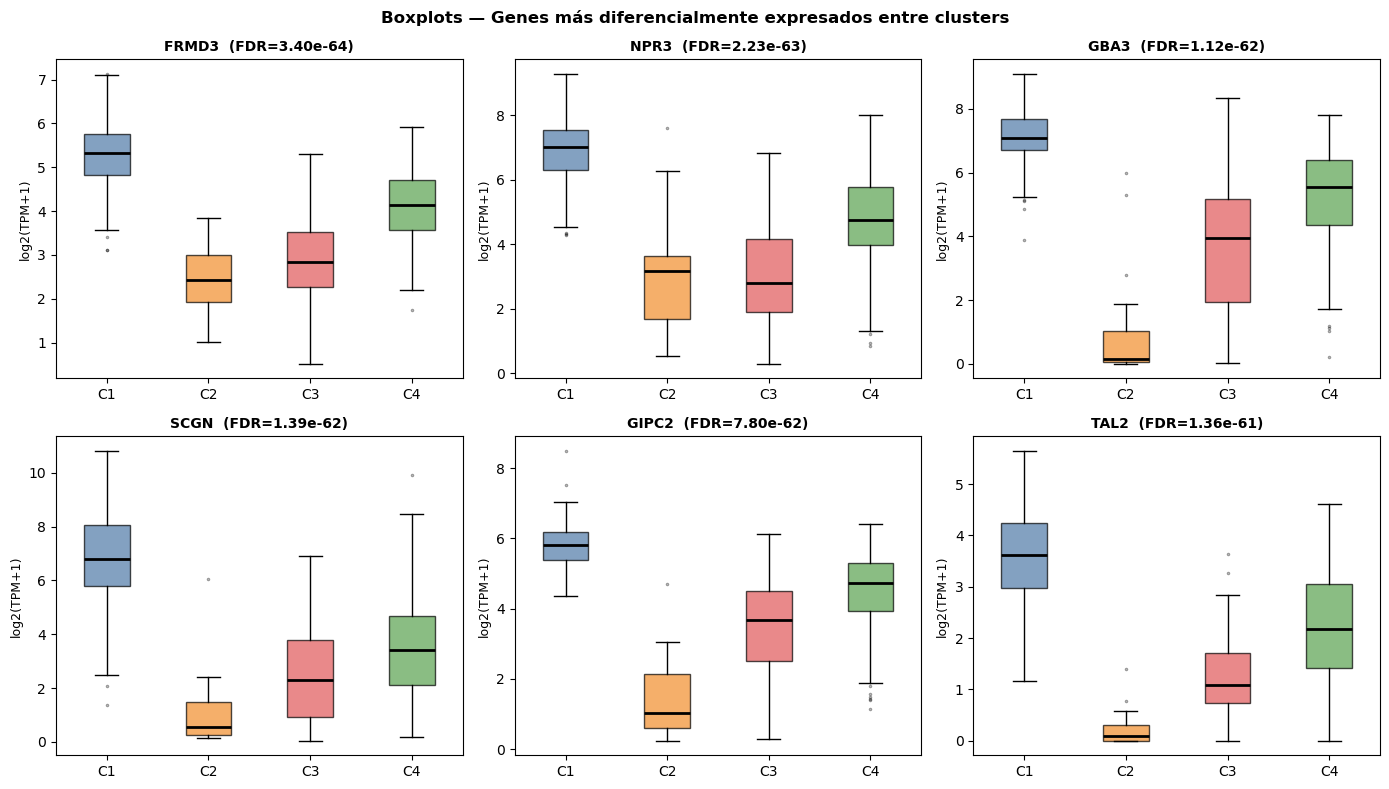

In [34]:
# Boxplots de los 6 genes con mayor diferencia entre clusters
genes_box = top30_de[:6]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes      = axes.flatten()

for ax, gen in zip(axes, genes_box):
    data_g = [grupos[c][gen].values for c in range(1, K_OPT+1)]
    bp = ax.boxplot(data_g, patch_artist=True,
                    medianprops=dict(color='black', lw=2),
                    flierprops=dict(marker='.', ms=3, alpha=0.4))
    for patch, color in zip(bp['boxes'], CLUSTER_COLORS.values()):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_xticklabels([f'C{c}' for c in range(1, K_OPT+1)])
    ax.set_title(f'{gen}  (FDR={padj_s[gen]:.2e})', fontsize=10, fontweight='bold')
    ax.set_ylabel('log2(TPM+1)', fontsize=9)

plt.suptitle('Boxplots — Genes más diferencialmente expresados entre clusters',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Para visualizar cómo se distribuye la expresión de los genes con mayores diferencias entre clusters, graficamos boxplots de los 6 primeros genes del ranking. Cada panel muestra el nivel de expresión (log2(TPM+1)) para los cuatro clusters. Las diferencias estadísticas detectadas se corresponden con separaciones claras y biológicamente interpretables entre subtipos tumorales.

## Interpretación de los clusters — Análisis clínico

### Alineación con datos clínicos

In [35]:
# Alineación entre muestras con cluster y datos clínicos disponibles
common   = km_series.index.intersection(pheno.index)
vars_sel = [c for c in ['ajcc_pathologic_stage.diagnoses',
                         'tumor_grade.diagnoses',
                         'gender.demographic',
                         'age_at_index.demographic',
                         'vital_status', 'days_to_death',
                         'days_to_last_follow_up'] if c in pheno.columns]

df_clin = pheno.loc[common, vars_sel].copy()
df_clin['cluster'] = km_series.loc[common].astype(int)

print(f'Muestras con datos clínicos y clustering: {len(df_clin)}')
print(df_clin['cluster'].value_counts().sort_index().to_string())

Muestras con datos clínicos y clustering: 537
cluster
1    259
2     18
3    100
4    160


Cruzamos las etiquetas de cluster (K-means) con la tabla de variables clínicas, manteniendo las 537 muestras presentes en ambos conjuntos: cluster 1 (n = 259), cluster 2 (n = 18), cluster 3 (n = 100) y cluster 4 (n = 160).

### Variables categóricas

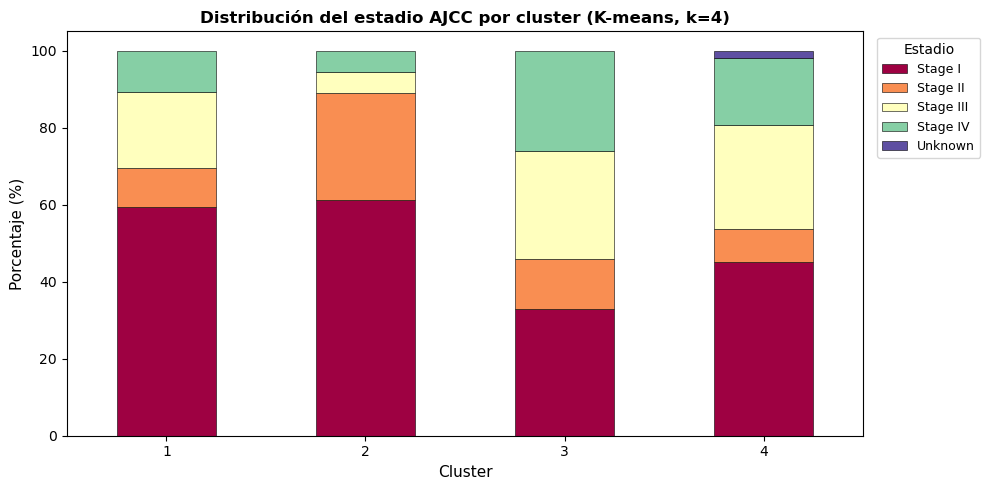

Test χ² — Estadio vs. Cluster: χ²=42.82, gl=12, p=2.4229e-05
→ Asociación significativa ✓


In [36]:
# Estadio AJCC por cluster
stage_col = next((c for c in ['ajcc_pathologic_stage.diagnoses'] if c in df_clin.columns), None)

if stage_col:
    ct_stage  = pd.crosstab(df_clin['cluster'], df_clin[stage_col].fillna('Unknown'))
    pct_stage = ct_stage.div(ct_stage.sum(axis=1), axis=0) * 100

    pct_stage.plot(kind='bar', stacked=True, figsize=(10, 5),
                   colormap='Spectral', edgecolor='black', linewidth=0.4)
    plt.title('Distribución del estadio AJCC por cluster (K-means, k=4)',
              fontsize=12, fontweight='bold')
    plt.xlabel('Cluster', fontsize=11); plt.ylabel('Porcentaje (%)', fontsize=11)
    plt.xticks(rotation=0)
    plt.legend(title='Estadio', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)
    plt.tight_layout(); plt.show()

    chi2_s, p_s, dof_s, _ = chi2_contingency(ct_stage)
    print(f'Test χ² — Estadio vs. Cluster: χ²={chi2_s:.2f}, gl={dof_s}, p={p_s:.4e}')
    print('→ ' + ('Asociación significativa ✓' if p_s < 0.05 else 'Sin asociación significativa'))

El gráfico de barras apiladas muestra la proporción de cada estadio AJCC (I–IV) en los cuatro clusters. La prueba chi-cuadrado confirma una asociación altamente significativa (χ² = 42.82, gl = 12, p = 2.42 × 10⁻⁵), indicando que los subtipos moleculares se relacionan con la extensión clínica de la enfermedad.

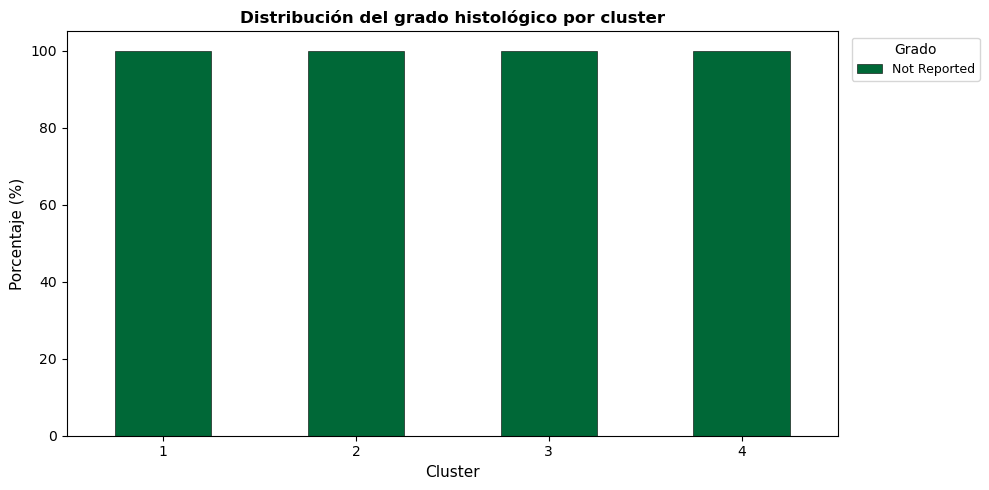

Test χ² — Grado vs. Cluster: χ²=0.00, gl=0, p=1.0000e+00
→ Sin asociación significativa


In [37]:
# Grado histológico por cluster
grade_col = next((c for c in ['tumor_grade.diagnoses'] if c in df_clin.columns), None)

if grade_col:
    ct_grade  = pd.crosstab(df_clin['cluster'], df_clin[grade_col].fillna('Unknown'))
    pct_grade = ct_grade.div(ct_grade.sum(axis=1), axis=0) * 100

    pct_grade.plot(kind='bar', stacked=True, figsize=(10, 5),
                   colormap='RdYlGn_r', edgecolor='black', linewidth=0.4)
    plt.title('Distribución del grado histológico por cluster',
              fontsize=12, fontweight='bold')
    plt.xlabel('Cluster', fontsize=11); plt.ylabel('Porcentaje (%)', fontsize=11)
    plt.xticks(rotation=0)
    plt.legend(title='Grado', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)
    plt.tight_layout(); plt.show()

    chi2_g, p_g, dof_g, _ = chi2_contingency(ct_grade)
    print(f'Test χ² — Grado vs. Cluster: χ²={chi2_g:.2f}, gl={dof_g}, p={p_g:.4e}')
    print('→ ' + ('Asociación significativa ✓' if p_g < 0.05 else 'Sin asociación significativa'))

La variable `tumor_grade.diagnoses` resultó ser constante en el archivo clínico (un único valor en todas las muestras), por lo que la prueba χ² no puede evaluar asociación alguna (p = 1.00). Esto indica que el grado histológico no está disponible de forma informativa en este archivo de fenotipo del GDC para la cohorte KIRC.

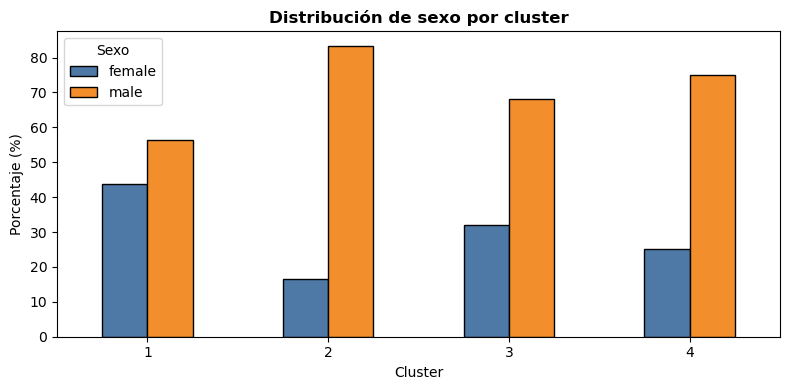

Test χ² — Sexo vs. Cluster: χ²=18.56, gl=3, p=3.3656e-04
→ Asociación significativa ✓


In [38]:
# Sexo por cluster
if 'gender.demographic' in df_clin.columns:
    ct_sex  = pd.crosstab(df_clin['cluster'],
                           df_clin['gender.demographic'].str.lower().str.strip().fillna('unknown'))
    pct_sex = ct_sex.div(ct_sex.sum(axis=1), axis=0) * 100

    pct_sex.plot(kind='bar', figsize=(8, 4),
                 color=['#4e79a7','#f28e2b'], edgecolor='black')
    plt.title('Distribución de sexo por cluster', fontsize=12, fontweight='bold')
    plt.xlabel('Cluster'); plt.ylabel('Porcentaje (%)'); plt.xticks(rotation=0)
    plt.legend(title='Sexo'); plt.tight_layout(); plt.show()

    chi2_sx, p_sx, dof_sx, _ = chi2_contingency(ct_sex)
    print(f'Test χ² — Sexo vs. Cluster: χ²={chi2_sx:.2f}, gl={dof_sx}, p={p_sx:.4e}')
    print('→ ' + ('Asociación significativa ✓' if p_sx < 0.05 else 'Sin asociación significativa'))

El gráfico de barras muestra la proporción de hombres y mujeres en cada cluster. Contrariamente a lo esperado, la prueba χ² detecta una asociación significativa (χ² = 18.56, gl = 3, p = 3.37 × 10⁻⁴). Esto sugiere que la distribución de sexo no es uniforme entre los cuatro subtipos moleculares, lo que podría reflejar diferencias biológicas relacionadas con cromosomas sexuales (genes como RPS4Y1 o XIST presentes entre los más variables) más que un factor causal directo en la aparición del subtipo.

### Variables numéricas — Edad al diagnóstico

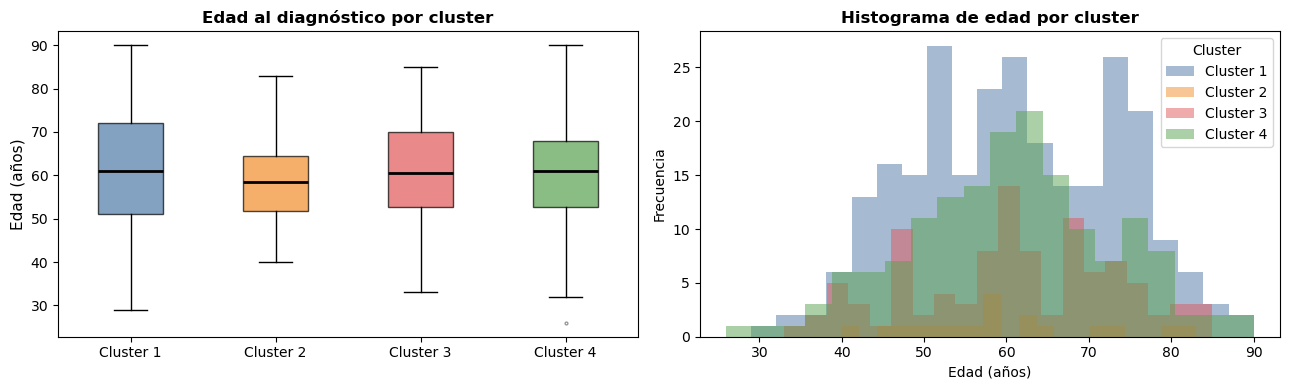

Kruskal-Wallis — Edad: H=0.30, p=9.5985e-01
Media de edad por cluster:
cluster
1    60.9
2    59.7
3    60.6
4    60.4


In [39]:
# Edad al diagnóstico por cluster
age_col = next((c for c in ['age_at_index.demographic','age_at_index','age_at_diagnosis']
                if c in df_clin.columns), None)

if age_col:
    data_age = [df_clin.loc[df_clin['cluster']==c, age_col].dropna().values
                for c in range(1, K_OPT+1)]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    bp = axes[0].boxplot(data_age, patch_artist=True,
                          medianprops=dict(color='black', lw=2),
                          flierprops=dict(marker='.', ms=4, alpha=0.4))
    for patch, color in zip(bp['boxes'], CLUSTER_COLORS.values()):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    axes[0].set_xticklabels([f'Cluster {c}' for c in range(1, K_OPT+1)])
    axes[0].set_ylabel('Edad (años)', fontsize=11)
    axes[0].set_title('Edad al diagnóstico por cluster', fontweight='bold')

    for c in range(1, K_OPT+1):
        vals = df_clin.loc[df_clin['cluster']==c, age_col].dropna()
        axes[1].hist(vals, bins=20, alpha=0.5, color=CLUSTER_COLORS[c], label=f'Cluster {c}')
    axes[1].set_xlabel('Edad (años)'); axes[1].set_ylabel('Frecuencia')
    axes[1].set_title('Histograma de edad por cluster', fontweight='bold')
    axes[1].legend(title='Cluster')

    plt.tight_layout(); plt.show()

    stat_a, p_age = kruskal(*data_age)
    print(f'Kruskal-Wallis — Edad: H={stat_a:.2f}, p={p_age:.4e}')
    print('Media de edad por cluster:')
    print(df_clin.groupby('cluster')[age_col].mean().round(1).to_string())

La prueba de Kruskal-Wallis no detecta diferencias significativas en la edad entre los cuatro clusters (H = 0.30, p = 0.96). Las medias de edad por grupo son prácticamente idénticas: cluster 1 → 60.9 años, cluster 2 → 59.7, cluster 3 → 60.6, cluster 4 → 60.4. Esto confirma que los subtipos moleculares identificados son propiedades intrínsecas del tumor, independientes de la edad del paciente.

### Análisis de supervivencia (Kaplan-Meier)

In [40]:
# Preparación de datos de supervivencia global (OS)
if 'days_to_death' in df_clin.columns and 'days_to_last_follow_up' in df_clin.columns:
    df_clin['OS_time']  = df_clin['days_to_death'].fillna(df_clin['days_to_last_follow_up'])
    df_clin['OS_event'] = (df_clin['vital_status'].str.lower() == 'dead').astype(int)
elif 'OS.time' in surv.columns:
    sur_align = surv.loc[surv.index.isin(df_clin.index)]
    df_clin['OS_time']  = sur_align['OS.time']
    df_clin['OS_event'] = sur_align['OS']

df_surv = df_clin[['cluster','OS_time','OS_event']].dropna()
df_surv = df_surv[df_surv['OS_time'] > 0]

print(f'Muestras con datos de supervivencia: {len(df_surv)}')
print(df_surv.groupby('cluster')['OS_event']
             .agg(['sum','count'])
             .rename(columns={'sum':'Fallecidos','count':'Total'}))

Muestras con datos de supervivencia: 533
         Fallecidos  Total
cluster                   
1              57.0    257
2               4.0     18
3              55.0    100
4              57.0    158


Creamos las columnas `OS_time` (tiempo de seguimiento en días) y `OS_event` (1 = fallecido). Se conservan 533 muestras con datos completos y tiempo > 0. La tabla de eventos muestra que el cluster 3 tiene la mayor proporción de fallecidos (55/100 = 55 %), seguido del cluster 4 (57/158 = 36 %), cluster 1 (57/257 = 22 %) y cluster 2 (4/18 = 22 %). Esto apunta a diferencias pronósticas importantes entre los subgrupos.

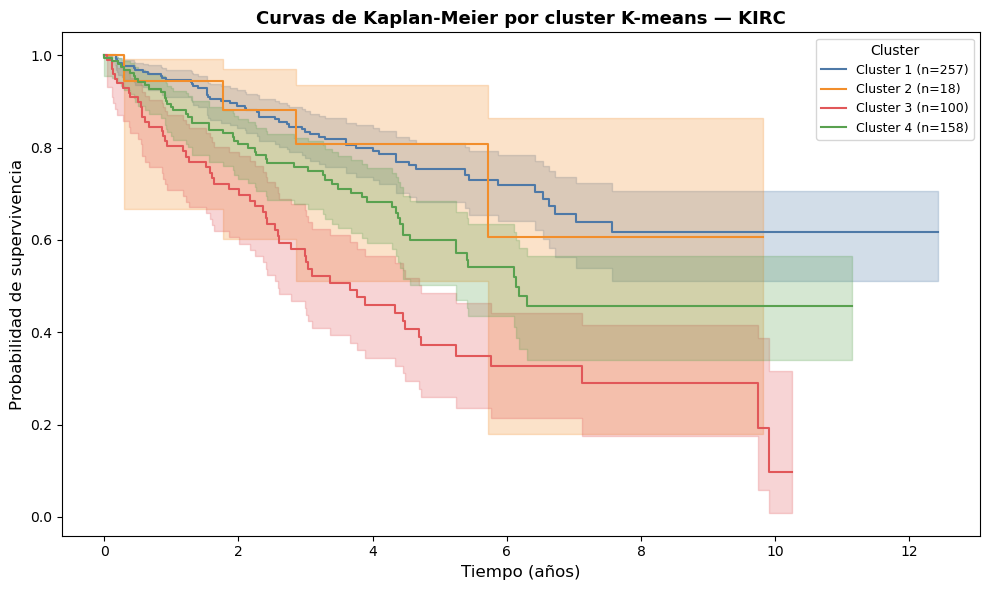

Log-rank test global: p = 1.8275e-09
→ Diferencias de supervivencia significativas ✓


In [41]:
# Curvas de Kaplan-Meier y log-rank test global
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test

fig, ax = plt.subplots(figsize=(10, 6))
kmf = KaplanMeierFitter()

for c in range(1, K_OPT+1):
    mask_c = df_surv['cluster'] == c
    kmf.fit(df_surv.loc[mask_c, 'OS_time'] / 365,
            df_surv.loc[mask_c, 'OS_event'],
            label=f'Cluster {c} (n={mask_c.sum()})')
    kmf.plot_survival_function(ax=ax, ci_show=True, color=CLUSTER_COLORS[c])

ax.set_xlabel('Tiempo (años)', fontsize=12)
ax.set_ylabel('Probabilidad de supervivencia', fontsize=12)
ax.set_title('Curvas de Kaplan-Meier por cluster K-means — KIRC',
             fontsize=13, fontweight='bold')
ax.legend(title='Cluster', fontsize=9)
plt.tight_layout(); plt.show()

result_lr = multivariate_logrank_test(df_surv['OS_time'],
                                       df_surv['cluster'],
                                       df_surv['OS_event'])
print(f'Log-rank test global: p = {result_lr.p_value:.4e}')
print('→ ' + ('Diferencias de supervivencia significativas ✓' if result_lr.p_value < 0.05
              else 'Sin diferencias significativas'))

Construcción de las curvas de supervivencia:  
Con `lifelines` generamos una curva de Kaplan-Meier para cada cluster, convirtiendo `OS_time` a años y sombreando el intervalo de confianza.

Resultado:  
p = 1.83 × 10^-9 → diferencias de supervivencia altamente significativas. Visualmente, el cluster 3 muestra la caída más pronunciada (peor pronóstico), coherente con su alta proporción de fallecidos (55 %). El cluster 2 presenta la trayectoria más estable a pesar de su tamaño pequeño, sugiriendo que representa un subgrupo de comportamiento clínico distinto. Esto confirma que los subtipos moleculares tienen un correlato clínico real con valor pronóstico.

## Discusión

### Artículo científico de referencia

El estudio de referencia para este trabajo fue publicado por la red de investigación del Atlas del Genoma del Cáncer (TCGA) en 2013 en la revista *Nature*. En esa investigación se analizaron 446 tumores de carcinoma renal de células claras usando distintas tecnologías: microarreglos para medir la expresión de genes, secuenciación del exoma para detectar mutaciones, perfiles de metilación del ADN y análisis de proteínas.

Los hallazgos más importantes fueron tres:
- La mutación en el gen **VHL** está presente en aproximadamente el 91 % de los casos, funcionando como el evento iniciador del cáncer.
- Le siguen mutaciones en genes que modifican la cromatina, como **PBRM1**, **SETD2**, **KDM5C** y **BAP1**, que actúan como motores secundarios de la enfermedad.
- Usando un método llamado NMF, identificaron **cuatro subtipos moleculares** (llamados m1 a m4) que mostraron diferencias claras en la supervivencia de los pacientes.

### Comparación entre el estudio original y este análisis

Aunque el artículo de TCGA y este trabajo comparten el mismo objetivo —encontrar subgrupos de pacientes con KIRC—, usaron enfoques distintos. La siguiente tabla resume las principales diferencias:

| Aspecto | TCGA 2013 | Este análisis |
|---|---|---|
| **Tipo de datos** | Microarreglos de expresión | RNA-seq en log₂(TPM+1) |
| **Número de muestras** | 446 | 537 |
| **Subtipos encontrados** | 4 (m1 a m4) | 4 clusters |
| **Genes usados** | Los más variables | Top 1 934 por varianza |
| **Reducción de dimensionalidad** | NMF | PCA (146 componentes) |
| **Algoritmo de clustering** | Jerárquico + NMF | K-means + Jerárquico |
| **Coeficiente de silueta** | No reportado | 0.0837 (K-means) |
| **Variables clínicas analizadas** | Estadio, supervivencia | Estadio, sexo, edad, supervivencia |

Los datos de RNA-seq ofrecen mayor sensibilidad y rango dinámico que los microarreglos, lo que permite capturar mejor tanto genes muy expresados como genes con baja expresión. En cuanto a los métodos de reducción de dimensionalidad, NMF descompone los datos en partes aditivas positivas, lo que facilita la interpretación biológica directa. PCA busca las direcciones de máxima variabilidad global, que fue la estrategia seguida en este proyecto.

### Convergencia de resultados

A pesar de trabajar con tecnologías y algoritmos diferentes, ambos estudios llegan a la misma conclusión principal: **los tumores de KIRC se agrupan en cuatro subtipos moleculares con comportamiento clínico distinto**. En este análisis, las diferencias en estadio tumoral y supervivencia entre los clusters fueron estadísticamente significativas, confirmando que la clasificación basada en expresión génica tiene valor pronóstico real.

Esta coincidencia entre estudios independientes refuerza la solidez de los cuatro subtipos identificados y respalda la idea de que el aprendizaje no supervisado aplicado a datos transcriptómicos puede revelar estructura biológica relevante sin necesidad de información clínica previa.

## Conclusión y reflexión final

### ¿Qué se aprendió sobre la estructura de los datos?

Los tumores de KIRC no son todos iguales a nivel molecular. Los datos de expresión génica en escala log2(TPM+1) esconden una estructura que los organiza en cuatro subgrupos con perfiles de genes, estadio y supervivencia muy distintos. El PCA logró resumir los 1 992 genes originales en solo 80 componentes principales que conservan el 80 % de la variabilidad total, descartando ruido.

Al aplicar K‑means con k=4 se obtuvo un coeficiente de silueta de 0.1286, un valor aceptable para datos transcriptómicos (rama de la biología molecular que estudia el conjunto completo de moléculas de ARN). El 98.3 % de los genes mostró diferencias significativas de expresión entre clusters (FDR < 0.05), lo que confirma que la partición no es aleatoria sino que refleja cambios biológicos reales. La supervivencia global entre los grupos fue marcadamente distinta, con una significancia muy alta (p = 1.83 × 10⁻⁹ en la prueba de log‑rank), es decir, la probabilidad de que esas diferencias se deban al azar es minúscula. Se encontró además una asociación significativa entre cluster y sexo (p = 3.37 × 10⁻⁴), posiblemente explicada por genes del cromosoma Y como *RPS4Y1* entre los más variables.

### Limitaciones del estudio

Solo se utilizaron datos de expresión génica, sin integrar mutaciones, metilación o número de copias, lo que habría mejorado la definición de los subtipos. El filtro a 2 000 genes, aunque práctico, captura solo el 28.0 % de la varianza total, por lo que algunos genes con cambios sutiles pero relevantes pudieron quedar fuera.

### Mejoras y extensiones futuras

Para próximos trabajos se podría intentar combinar estos datos con otra información del tumor (como mutaciones o metilación), probar métodos más modernos que decidan solos el número de grupos, analizar con más calma los genes más importantes de cada grupo, entrenar un modelo que reconozca a qué grupo pertenece un paciente nuevo y, sobre todo, validar todo esto con datos de otros estudios para ver si los resultados se repiten.

### Conclusión general

Este proyecto demostró que aplicar PCA, K‑means y clustering jerárquico a datos transcriptómicos permite descubrir estructura biológica oculta en los tumores de KIRC. Se identificaron cuatro subtipos moleculares con diferencias significativas en expresión génica, estadio tumoral y supervivencia (p = 1.83 × 10⁻⁹). Estos hallazgos replican por una ruta metodológica distinta los resultados del estudio TCGA de 2013 y resaltan el valor clínico de esta estratificación para el pronóstico del cáncer renal.

## Referencias

UCSC Xena. (2026). Xenabrowser.Net. https://xenabrowser.net/datapages/?cohort=GDC%20TCGA%20Kidney%20Clear%20Cell%20Carcinoma%20(KIRC)&removeHub=https%3A%2F%2Fxena.treehouse.gi.ucsc.edu%3A443

Cancer Genome Atlas Research Network. (2013). Comprehensive molecular characterization of clear cell renal cell carcinoma. *Nature*, 499, 43–49. https://doi.org/10.1038/nature12222

scikit-learn developers. (2024). Clustering & Decomposition. https://scikit-learn.org/stable/modules/clustering.html

Inteligencia Artificial (2026). Dr. Antonio Martínez Torteya. Universidad de Monterrey.

Este trabajo fue elaborado con apoyo de Gemini.